In [50]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


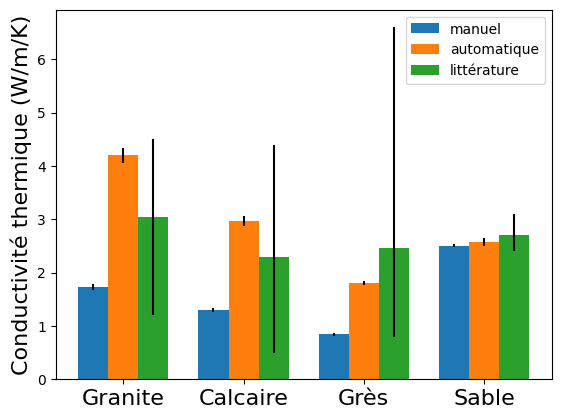

In [57]:
# [granite, calcaire, gres, sable]
manuel = [1.73,1.3,0.841,2.507]
merr = [0.06,0.038,0.032,0.024]
automatique = [4.2,2.97,1.81,2.57]
aerr = [0.14,0.1,0.04,0.08]
litterature = [3.05,2.29,2.47,2.7]
lerr_lower = [1.85,1.79,1.67,0.3]
lerr_upper = [1.45,2.11,4.13,0.4]
fig, ax = plt.subplots()
#position en x, valeur y, erreur, largeur, label
ax.bar([0.1,0.5,0.9,1.3],manuel,yerr=merr, width=0.1, label='manuel')
ax.bar([0.2,0.6,1,1.4],automatique, yerr=aerr,width=0.1, label ='automatique')
ax.bar([0.3,0.7,1.1,1.5],litterature,yerr=[lerr_lower,lerr_upper], width=0.1, label ='littérature')
ax.legend()

# axe x
ax.set_xticks([0.2, 0.6, 1, 1.4])
ax.set_xticklabels(['Granite', 'Calcaire', 'Grès', 'Sable'], fontsize = 16)
ax.set_ylabel("Conductivité thermique (W/m/K)",fontsize=16)

#plt.savefig("C:/Users/Nicolas Onillon/PycharmProjects/TP_geologie/hist_thermique.eps")

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


 gradient auto: [0.023346303501945526, 0.03314917127071823, 0.0202020202020202, 0.014285714285714285] W/m
 gradient manuel: [0.023932987634623055, 0.0713436385255648, 0.04615384615384615, 0.03468208092485549] W/m
 température auto [10, 10.700389105058365, 14.015306232130188, 18.055710272534228, 19.055710272534228] celcius
 erreur T auto [0, 0.04, 0.06, 0.11, 0.18] celcius
 température manuelle [10, 10.717989629038692, 17.852353481595173, 27.083122712364403, 29.510868377104288] celcius
 erreur T man [0, 0.012, 0.028, 0.047, 0.077] celcius


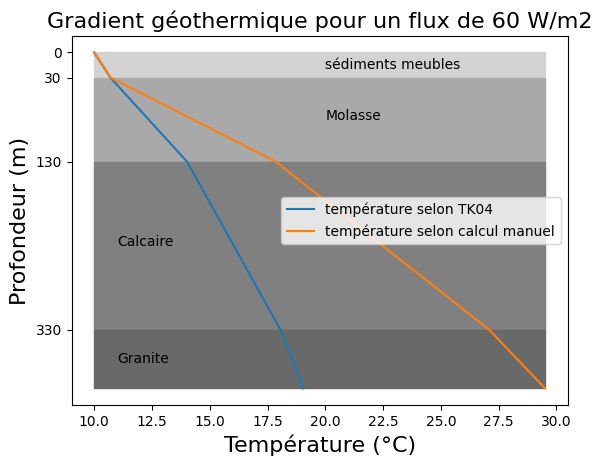

In [56]:
# gradient en W/m/K
#sable,gres,calcaire,granite
kauto = [2.57,1.81,2.97,4.2]
kautoerr = [0.04,0.02,0.05,0.07]
kman = [2.507,0.841,1.3,1.73]
kmanerr = [0.012,0.016,0.019,0.03]
#puissance chauffe
heat = 0.06 # W/m2
#gradient geothermique en W/m
gradauto = [heat/k for k in kauto]
gradman = [heat/k for k in kman]
depth = [0, 30, 130, 330, 400]
#temperature en surface (celsius)
Tzero = 10
print(f" gradient auto: {gradauto} W/m")
print(f" gradient manuel: {gradman} W/m")

#automatique
T = [Tzero]
Terr = [0]
for k in range(len(kauto)):
    t = T[k]+(depth[k+1]-depth[k])*gradauto[k]
    T.append(t)
    terr = Terr[k] + kautoerr[k]
    Terr.append(terr)
#manuel
Tm = [Tzero]
Tmanerr = [0]
for k in range(len(kauto)):
    t = Tm[k]+(depth[k+1]-depth[k])*gradman[k]
    Tm.append(t)
    terr = Tmanerr[k] + kmanerr[k]
    Tmanerr.append(terr)

print(f" température auto {T} celcius")
print(f" erreur T auto {Terr} celcius")
print(f" température manuelle {Tm} celcius")
print(f" erreur T man {Tmanerr} celcius")

fig, ax = plt.subplots()
ax.plot(T,depth, label = 'température selon TK04')
ax.plot(Tm,depth, label = 'température selon calcul manuel')
ax.set_yticks(depth[:-1]) #les limites de profondeur
ax.legend()
ax.set_xlabel('Température (°C)',fontsize=16)
ax.set_ylabel('Profondeur (m)',fontsize=16)
ax.set_title('Gradient géothermique pour un flux de 60 W/m2',fontsize=16)

#remplissage, x car horizontal
ax.fill_betweenx([depth[0], depth[1]], Tm[0], Tm[-1], color='lightgray', label='Sédiments meubles')
ax.fill_betweenx([depth[1], depth[2]], Tm[0], Tm[-1], color='darkgray', label='Molasse')
ax.fill_betweenx([depth[2], depth[3]], Tm[0], Tm[-1], color='gray', label='Calcaire')
ax.fill_betweenx([depth[3], depth[4]], Tm[0], Tm[-1], color='dimgray', label='Cristallin')

#texte
ax.text(20,20,'sédiments meubles')
ax.text(20,80,'Molasse')
ax.text(11,230,'Calcaire')
ax.text(11,370,'Granite')

ax.invert_yaxis()

#plt.savefig("C:/Users/Nicolas Onillon/PycharmProjects/TP_geologie/gradient.eps")